# Assessment 8: K-Means vs. DBSCAN

**Submitted by:**
* Benedict S. Caliba
* Marcelo B. Cosme
* Aaron Kane M. Dungca
  
**Date Submitted:** April 24, 2026

---

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)

# **Data Preparation**

## **Load Dataset**

In [2]:
# Load the dataset
df = pd.read_csv("credit_card.csv")

# Display the first 5 rows
print("="*75)
print("FIRST 5 ROWS OF THE CREDIT CARD DATASET".center(80))
print("="*75 + "\n")
print(df.head())

                    FIRST 5 ROWS OF THE CREDIT CARD DATASET                     

  CUST_ID      BALANCE  PURCHASES  INSTALLMENTS_PURCHASES  CASH_ADVANCE  \
0  C10001    40.900749      95.40                    95.4      0.000000   
1  C10002  3202.467416       0.00                     0.0   6442.945483   
2  C10003  2495.148862     773.17                     0.0      0.000000   
3  C10004  1666.670542    1499.00                     0.0    205.788017   
4  C10005   817.714335      16.00                     0.0      0.000000   

   CREDIT_LIMIT     PAYMENTS  MINIMUM_PAYMENTS  TENURE  
0        1000.0   201.802084        139.509787      12  
1        7000.0  4103.032597       1072.340217      12  
2        7500.0   622.066742        627.284787      12  
3        7500.0     0.000000        312.343947      12  
4        1200.0   678.334763        244.791237      12  


## **Data Cleaning**

In [3]:
# Remove unnecessary columns
clean_df = df[["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS", "MINIMUM_PAYMENTS"]]

# Display the filtered dataset
print("="*70)
print("FIRST 5 ROWS OF THE FILTERED DATASET".center(65))
print("="*70 + "\n")
print(clean_df.head())

               FIRST 5 ROWS OF THE FILTERED DATASET              

       BALANCE  PURCHASES  CASH_ADVANCE  CREDIT_LIMIT     PAYMENTS  \
0    40.900749      95.40      0.000000        1000.0   201.802084   
1  3202.467416       0.00   6442.945483        7000.0  4103.032597   
2  2495.148862     773.17      0.000000        7500.0   622.066742   
3  1666.670542    1499.00    205.788017        7500.0     0.000000   
4   817.714335      16.00      0.000000        1200.0   678.334763   

   MINIMUM_PAYMENTS  
0        139.509787  
1       1072.340217  
2        627.284787  
3        312.343947  
4        244.791237  


In [4]:
# Extract the dataset shape
rows_num, cols_num = clean_df.shape

# Display dataset shape (rows and columns)
print("="*25)
print("DATASET SHAPE".center(25))
print("="*25 + "\n")
print(f"Rows: {rows_num}")
print(f"Columns: {cols_num}")

      DATASET SHAPE      

Rows: 8950
Columns: 6


In [5]:
# Dislay dataset non-null count and datatypes
print("="*55)
print("DATASET INFORMATION".center(55))
print("="*55 + "\n")
clean_df.info()

                  DATASET INFORMATION                  

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   BALANCE           8950 non-null   float64
 1   PURCHASES         8950 non-null   float64
 2   CASH_ADVANCE      8950 non-null   float64
 3   CREDIT_LIMIT      8950 non-null   float64
 4   PAYMENTS          8950 non-null   float64
 5   MINIMUM_PAYMENTS  8950 non-null   float64
dtypes: float64(6)
memory usage: 419.7 KB


**Note:** Features ``CREDIT_LIMIT`` and ``MINIMUM_PAYMENTS`` have display an incomplete count of non-null values. Therefore, a need to remove these rows is required.

In [6]:
# Remove rows with NaN values
clean_df = clean_df.dropna()

# Extract the dataset shape again
rows_num, cols_num = clean_df.shape

# Display the dataframe shape again
print("="*25)
print("DATASET SHAPE".center(25))
print("="*25 + "\n")
print(f"Rows: {rows_num}")
print(f"Columns: {cols_num}")

      DATASET SHAPE      

Rows: 8950
Columns: 6


**Note:** From 8650 down to 8636 rows, there are 14 rows that have been removed as they contain missing values.

## **Exploratory Data Analysis**

In [7]:
# Display descriptive statistics
print("="*75)
print("DESCRIPTIVE STATISTICS (NUMERICAL VARIABLES)".center(73))
print("="*75 + "\n")

des_stats = clean_df.describe()
print(des_stats)

               DESCRIPTIVE STATISTICS (NUMERICAL VARIABLES)              

            BALANCE     PURCHASES  CASH_ADVANCE  CREDIT_LIMIT      PAYMENTS  \
count   8950.000000   8950.000000   8950.000000   8950.000000   8950.000000   
mean    1564.474828   1003.204834    978.871112   4494.282473   1733.143852   
std     2081.531879   2136.634782   2097.163877   3638.646702   2895.063757   
min        0.000000      0.000000      0.000000     50.000000      0.000000   
25%      128.281915     39.635000      0.000000   1600.000000    383.276166   
50%      873.385231    361.280000      0.000000   3000.000000    856.901546   
75%     2054.140036   1110.130000   1113.821139   6500.000000   1901.134317   
max    19043.138560  49039.570000  47137.211760  30000.000000  50721.483360   

       MINIMUM_PAYMENTS  
count       8950.000000  
mean         844.906767  
std         2332.792322  
min            0.019163  
25%          170.857654  
50%          312.343947  
75%          788.713501  
max  

In [8]:
# Display interpretation of numerical varibales
print("="*70)
print("INTERPRETATION OF NUMERICAL VARIABLES".center(70))
print("="*70)

for col in des_stats.columns:
    mean = des_stats[col]['mean']
    std = des_stats[col]['std']
    min_value = des_stats[col]['min']
    max_value = des_stats[col]['max']
    lower_boundary = des_stats[col]['mean'] - 3*des_stats[col]['std']
    upper_boundary = des_stats[col]['mean'] + 3*des_stats[col]['std']
    
    print(f"\n{col} variable:")
    print(f"• Min: {min_value}")
    print(f"• Max: {max_value}")  
    print(f"• Mean: {mean:.3f}")
    print(f"• Standard Deviation: {std:.3f}")
    print(f"• Confidence Interval (Approx. 99%): {lower_boundary:.3f} to {upper_boundary:.3f}")
    print(f"• {"There are potential outliers in this variable." if (lower_boundary > min_value or upper_boundary < max_value) else "There are no outliers in this variable."}")

                INTERPRETATION OF NUMERICAL VARIABLES                 

BALANCE variable:
• Min: 0.0
• Max: 19043.13856
• Mean: 1564.475
• Standard Deviation: 2081.532
• Confidence Interval (Approx. 99%): -4680.121 to 7809.070
• There are potential outliers in this variable.

PURCHASES variable:
• Min: 0.0
• Max: 49039.57
• Mean: 1003.205
• Standard Deviation: 2136.635
• Confidence Interval (Approx. 99%): -5406.700 to 7413.109
• There are potential outliers in this variable.

CASH_ADVANCE variable:
• Min: 0.0
• Max: 47137.211760000006
• Mean: 978.871
• Standard Deviation: 2097.164
• Confidence Interval (Approx. 99%): -5312.621 to 7270.363
• There are potential outliers in this variable.

CREDIT_LIMIT variable:
• Min: 50.0
• Max: 30000.0
• Mean: 4494.282
• Standard Deviation: 3638.647
• Confidence Interval (Approx. 99%): -6421.658 to 15410.223
• There are potential outliers in this variable.

PAYMENTS variable:
• Min: 0.0
• Max: 50721.483360000006
• Mean: 1733.144
• Standard Deviation: 

### **Scale Values**

In [9]:
# Extract values
X = clean_df.values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Check the mean and standard deviation of the scaled X
print("Checking the mean and standard deviation of the scaled dataset.")
print(f"Mean: {X_scaled[:, 0].mean():.4f}") # Must be 0
print(f"Standard Deviation: {X_scaled[:, 0].std():.4f}") # Must be 1

Checking the mean and standard deviation of the scaled dataset.
Mean: 0.0000
Standard Deviation: 1.0000


### **Feature Distribution**

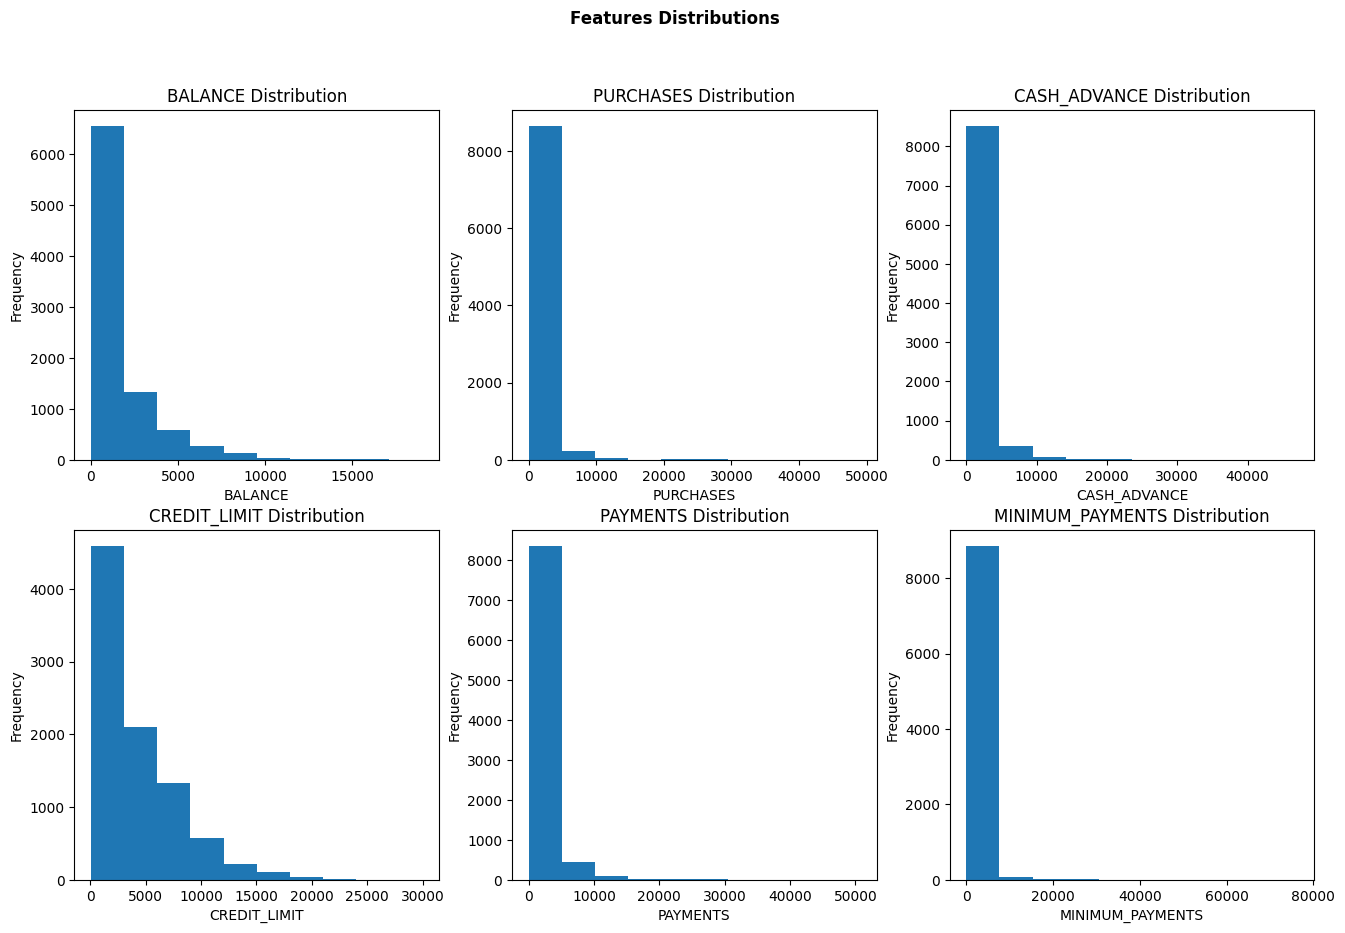

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Features Distributions", fontweight="bold")

axes = axes.flatten()

for idx, col in enumerate(clean_df.columns):
    axes[idx].hist(clean_df[col])
    axes[idx].set_title(f"{col} Distribution")
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Frequency")

**Note:** Based from the figure, all histograms show right-skewed distributions where there is less frequency as the X-value increases.

### **Correlation Heatmap**

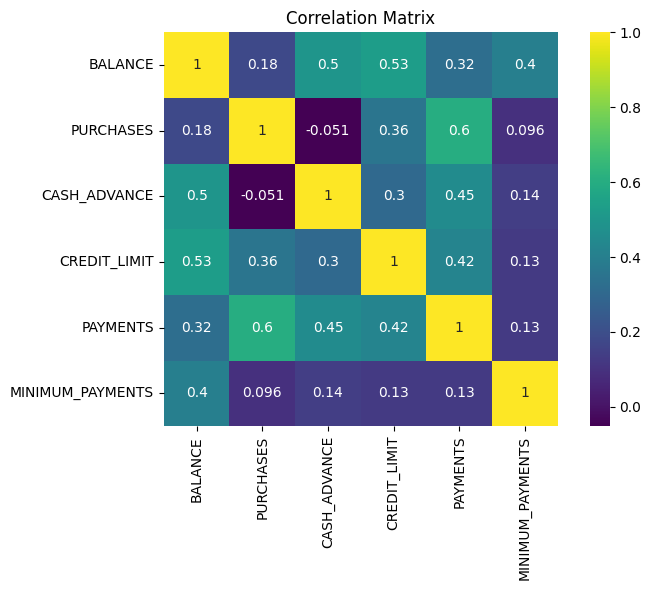

In [11]:
# Creating the correlation matrix
corr = clean_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, cmap='viridis', annot=True, square=1)

plt.title('Correlation Matrix')

plt.tight_layout()

**Insights:**
* Based from the correlation matrix heatmap, the pairs of variables that have a strong correlation are ``PAYMENTS-PURCHASES``, ``CREDIT_LIMIT-BALANCE``, and ``CASH_ADVANCE-BALANCE``.
* To give more emphasis on the pair ``PAYMENTS-PURCHASES``, it highly suggests that people who always spend their money tend to be an active payers, too as it is the highest correlation.
* Moreover, for ``CREDIT_LIMIT-BALANCE``, it indicates that some customers are in debt where their balance are not yet fully paid, exceeding their credit limit.
* For ``CASH_ADVANCE-BALANCE``, it implies that people who borrow cash more often tend to have hi

# **K-Means Clustering**

## **Choosing K**

### **Elbow Method**

Running K-Means for K = 1 to 10...

  K= 1  |  WCSS = 53700.00
  K= 2  |  WCSS = 39496.98
  K= 3  |  WCSS = 33979.12
  K= 4  |  WCSS = 29402.19
  K= 5  |  WCSS = 25529.35
  K= 6  |  WCSS = 22534.20
  K= 7  |  WCSS = 20258.66
  K= 8  |  WCSS = 18461.71
  K= 9  |  WCSS = 16995.67
  K=10  |  WCSS = 15874.66


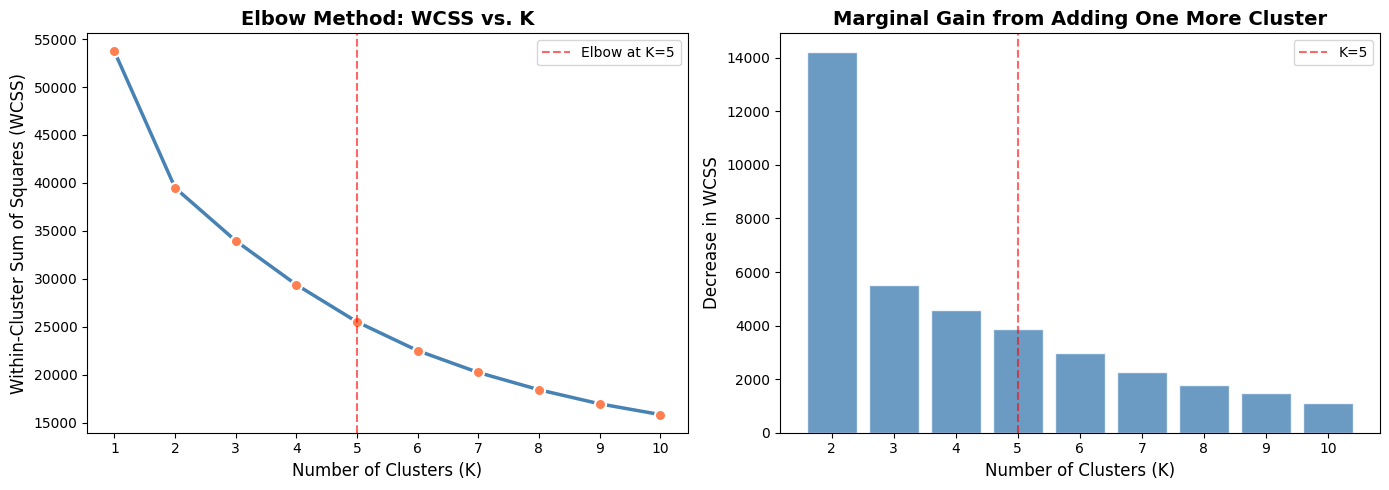


The elbow curve shows a sharp bend around K=5.
Beyond K=5, additional clusters yield diminishing returns.
The marginal gain plot makes this easier to see numerically.


In [12]:
K_range = range(1, 11)
wcss = []

print("Running K-Means for K = 1 to 10...")
print()

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42, max_iter=300)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
    print(f"  K={k:2d}  |  WCSS = {km.inertia_:8.2f}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
ax1.plot(K_range, wcss, marker='o', color='steelblue', linewidth=2.5,
         markersize=8, markerfacecolor='coral', markeredgecolor='white', markeredgewidth=1.5)
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
ax1.set_title('Elbow Method: WCSS vs. K', fontsize=14, fontweight='bold')
ax1.set_xticks(list(K_range))
ax1.axvline(x=5, color='red', linestyle='--', alpha=0.6, label='Elbow at K=5')
ax1.legend()

# Marginal decrease in WCSS
delta_wcss = [wcss[i-1] - wcss[i] for i in range(1, len(wcss))]
ax2.bar(range(2, 11), delta_wcss, color='steelblue', alpha=0.8, edgecolor='white')
ax2.set_xlabel('Number of Clusters (K)', fontsize=12)
ax2.set_ylabel('Decrease in WCSS', fontsize=12)
ax2.set_title('Marginal Gain from Adding One More Cluster', fontsize=14, fontweight='bold')
ax2.set_xticks(range(2, 11))
ax2.axvline(x=5, color='red', linestyle='--', alpha=0.6, label='K=5')
ax2.legend()

plt.tight_layout()
plt.show()

print()
print("The elbow curve shows a sharp bend around K=5.")
print("Beyond K=5, additional clusters yield diminishing returns.")
print("The marginal gain plot makes this easier to see numerically.")

### **Silhouette Scores**

Silhouette Analysis:
----------------------------------------
    K  |   Mean Silhouette Score
----------------------------------------
  K=2  |                  0.5627
  K=3  |                  0.5153
  K=4  |                  0.5028
  K=5  |                  0.3812
  K=6  |                  0.4182
  K=7  |                  0.3499
----------------------------------------


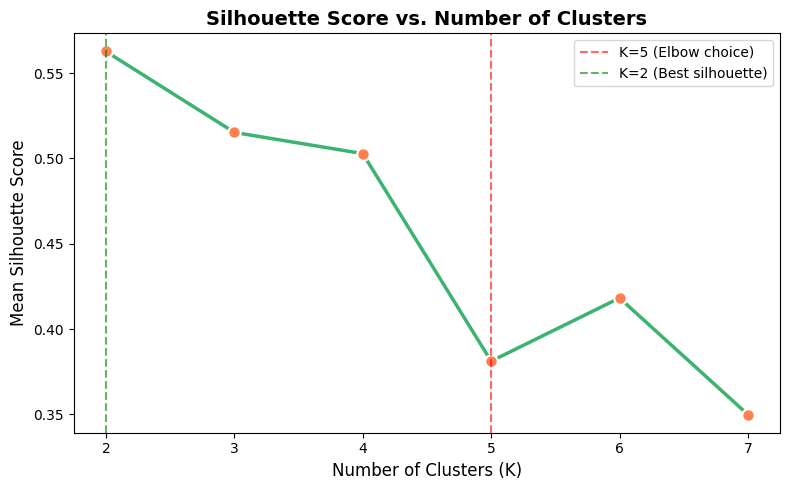


Best K by silhouette score: K=2 (score = 0.5627)


In [13]:
K_test = range(2, 8)
silhouette_scores = []

print("Silhouette Analysis:")
print("-" * 40)
print(f"{'K':>5}  |  {'Mean Silhouette Score':>22}")
print("-" * 40)

for k in K_test:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42, max_iter=300)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"  K={k}  |  {score:>22.4f}")

print("-" * 40)

# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(K_test, silhouette_scores, marker='o', color='mediumseagreen', linewidth=2.5,
         markersize=9, markerfacecolor='coral', markeredgecolor='white', markeredgewidth=1.5)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Mean Silhouette Score', fontsize=12)
plt.title('Silhouette Score vs. Number of Clusters', fontsize=14, fontweight='bold')
plt.xticks(list(K_test))
plt.axvline(x=5, color='red', linestyle='--', alpha=0.6, label='K=5 (Elbow choice)')
best_k = list(K_test)[silhouette_scores.index(max(silhouette_scores))]
plt.axvline(x=best_k, color='green', linestyle='--', alpha=0.6, label=f'K={best_k} (Best silhouette)')
plt.legend()
plt.tight_layout()
plt.show()

print()
print(f"Best K by silhouette score: K={best_k} (score = {max(silhouette_scores):.4f})")

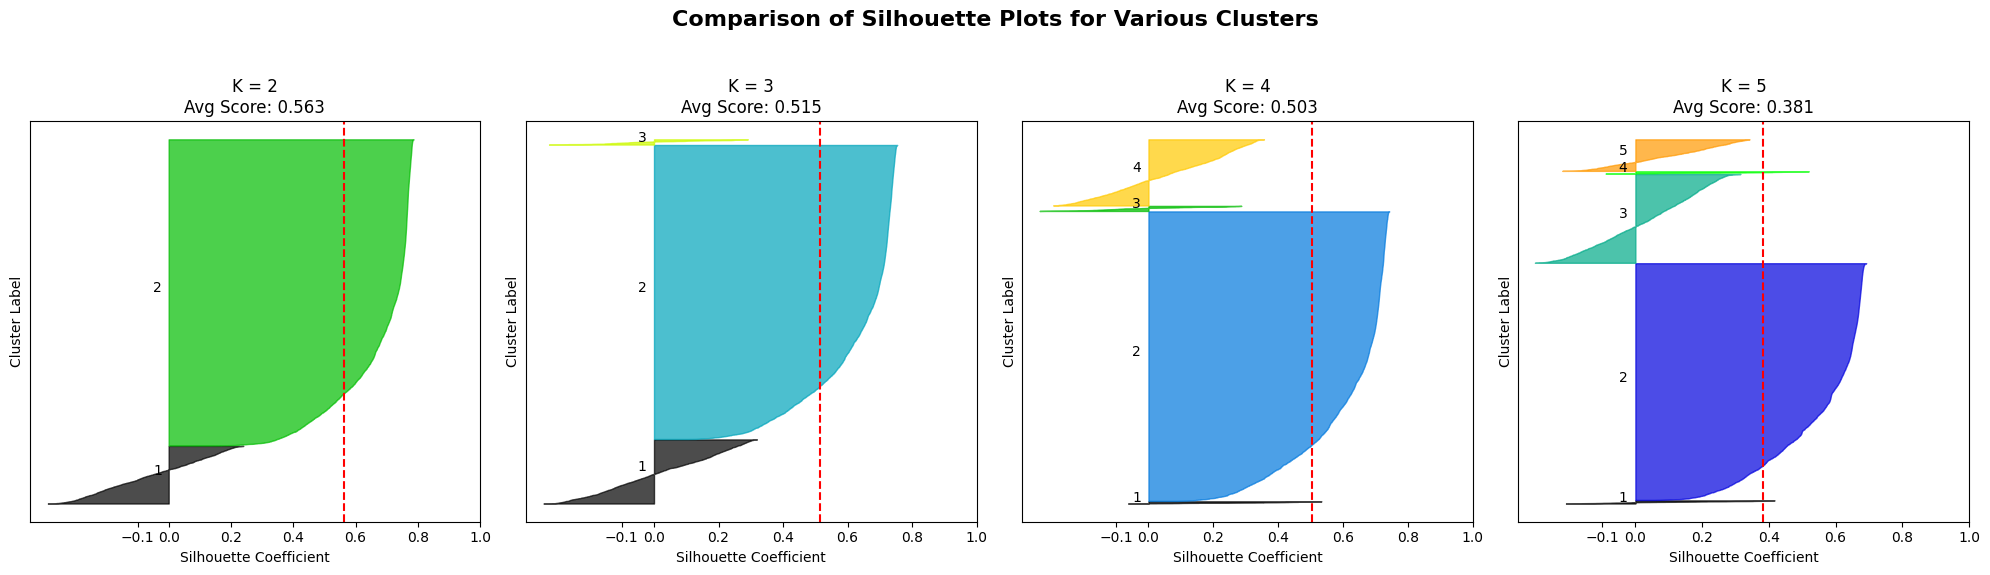

In [14]:
# Define the range of K you want to compare
range_n_clusters = [2, 3, 4, 5]
km_final = KMeans(n_clusters=best_k, init='k-means++', n_init=10, random_state=42, max_iter=300)
labels_final = km_final.fit_predict(X_scaled)

# Create a figure with subplots (1 row, multiple columns)
fig, axes = plt.subplots(1, len(range_n_clusters), figsize=(20, 6))

for idx, n_clusters in enumerate(range_n_clusters):
    ax = axes[idx]
    
    # Initialize and fit KMeans
    clusterer = KMeans(n_clusters=n_clusters, init='k-means++', n_init=10, random_state=42)
    cluster_labels = clusterer.fit_predict(X_scaled)
    
    # Calculate scores
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)
    
    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        
        color = cm.nipy_spectral(float(i) / n_clusters)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)
        
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i+1))
        y_lower = y_upper + 10 

    ax.set_title(f"K = {n_clusters}\nAvg Score: {silhouette_avg:.3f}")
    ax.set_xlabel("Silhouette Coefficient")
    ax.set_ylabel("Cluster Label")
    
    # Vertical line for average silhouette score of all values
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax.set_yticks([])  # Clear the yaxis labels / ticks
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

plt.suptitle("Comparison of Silhouette Plots for Various Clusters", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

* Comparing the Silhouette Score and the Elbow Method we can conclude that 2 is the optimal number of K, with it having the least amount of useless clusters.
* The Cluster 1 is clearly the star of the show since almost all it's points are above the silhouette score, this basically means that the points from cluster 1 are both very similar to each other and also far from the other cluster.
* I assume the cluster with a negative coefficient are because the dataset doesn't have hard boundaries and instead it's a dataset of spectrums.
* We will proceed with K = 2 because it has both a low silhouette score and no unnecessary clusters

## **Fit K-Means with Chosen K**

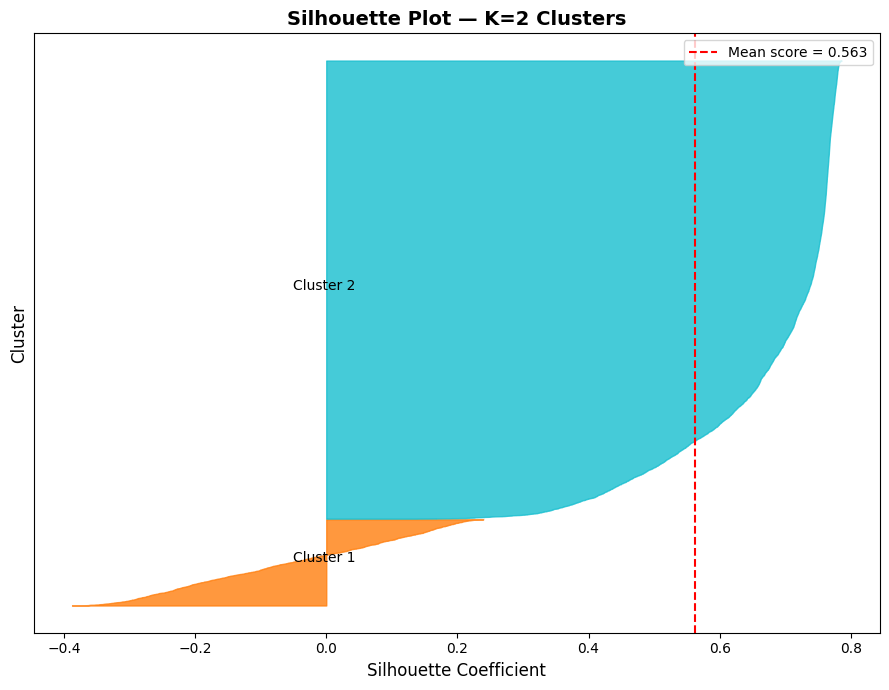

In [15]:
K_final = 2

silhouette_vals = silhouette_samples(X_scaled, labels_final)
avg_score = silhouette_score(X_scaled, labels_final)

fig, ax = plt.subplots(figsize=(9, 7))
y_lower = 10
colors = cm.tab10(np.linspace(0.1, 0.9, K_final))

for i in range(K_final):
    cluster_sil_vals = silhouette_vals[labels_final == i]
    cluster_sil_vals.sort()
    cluster_size = len(cluster_sil_vals)
    y_upper = y_lower + cluster_size
    
    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, cluster_sil_vals,
                     facecolor=colors[i], edgecolor=colors[i], alpha=0.8)
    ax.text(-0.05, y_lower + 0.5 * cluster_size, f'Cluster {i+1}', fontsize=10)
    y_lower = y_upper + 10

ax.axvline(x=avg_score, color='red', linestyle='--', linewidth=1.5,
           label=f'Mean score = {avg_score:.3f}')
ax.set_xlabel('Silhouette Coefficient', fontsize=12)
ax.set_ylabel('Cluster', fontsize=12)
ax.set_title(f'Silhouette Plot — K={K_final} Clusters', fontsize=14, fontweight='bold')
ax.set_yticks([])
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

Cluster Centroids (Original Units):
   BALANCE  PURCHASES  CASH_ADVANCE  CREDIT_LIMIT  PAYMENTS  MINIMUM_PAYMENTS
0  4976.19    2521.20       3505.07       9533.76   5019.76           2609.38
1   921.64     717.18        502.88       3544.74   1113.88            512.44


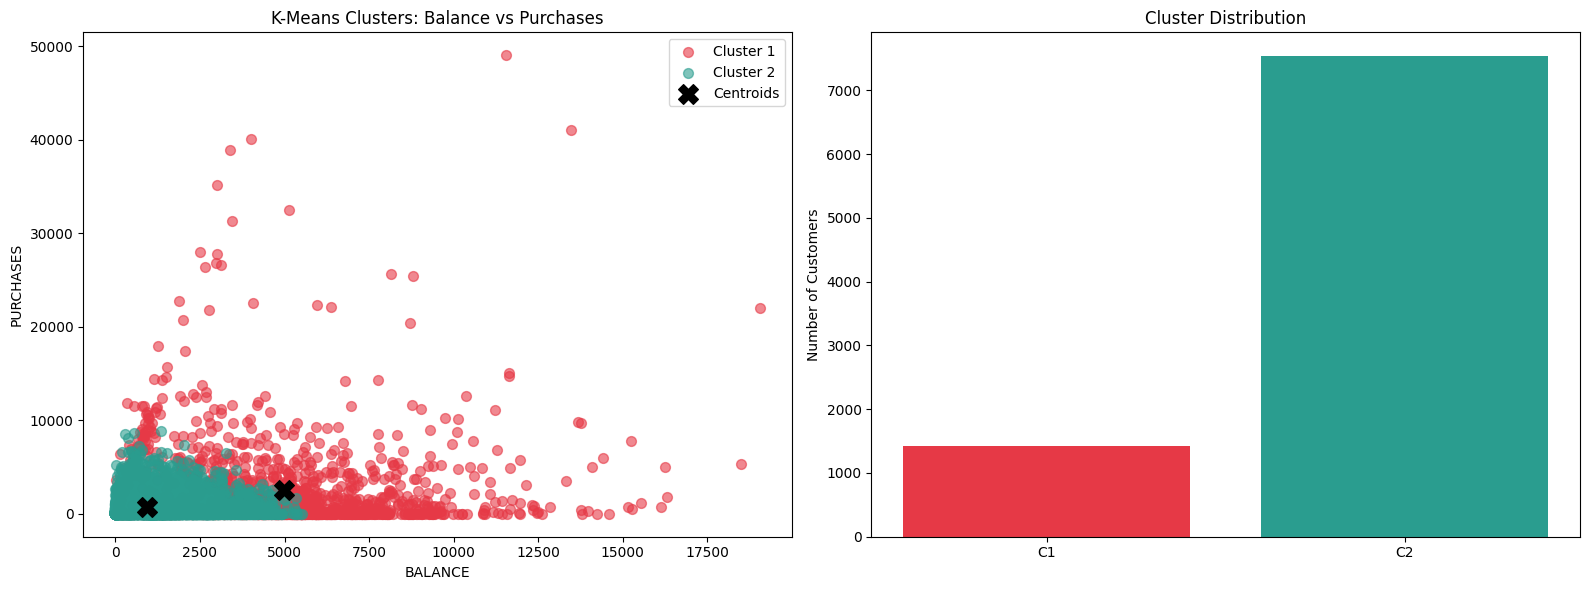


Silhouette Score: 0.5627
Davies-Bouldin Index: 1.3079
Calinski-Harabasz Index: 3217.6814



In [16]:
K_final = 2

# CREATE FINAL DF
clean_df = df.dropna(subset=['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS']).copy()
clean_df['KMeans_Cluster'] = km_final.labels_

# CALCULATE METRICS
s_score_k = silhouette_score(X_scaled, km_final.labels_)
db_index_k = davies_bouldin_score(X_scaled, km_final.labels_)
ch_index_k = calinski_harabasz_score(X_scaled, km_final.labels_)

# CENTROIDS
centers_original = scaler.inverse_transform(km_final.cluster_centers_)
features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS']
centroids_df = pd.DataFrame(centers_original, columns=features)
print("Cluster Centroids (Original Units):")
print(centroids_df.round(2))

# PLOTTING
palette = ['#e63946', '#2a9d8f', '#e9c46a', '#457b9d', '#a8dadc']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for i in range(K_final):
    # This now finds 'KMeans_Cluster' because it's looking in clean_df
    mask = clean_df['KMeans_Cluster'] == i
    ax1.scatter(clean_df.loc[mask, 'BALANCE'], clean_df.loc[mask, 'PURCHASES'],
                c=palette[i], s=50, alpha=0.6, label=f'Cluster {i+1}')

# Overlay Centroids
ax1.scatter(centers_original[:, 0], centers_original[:, 1], 
            c='black', marker='X', s=200, label='Centroids')
ax1.set_xlabel('BALANCE')
ax1.set_ylabel('PURCHASES')
ax1.set_title('K-Means Clusters: Balance vs Purchases')
ax1.legend()

# Distribution Plot
counts = clean_df['KMeans_Cluster'].value_counts().sort_index()
ax2.bar([f'C{i+1}' for i in range(K_final)], counts, color=palette)
ax2.set_title('Cluster Distribution')
ax2.set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()

print(f"\nSilhouette Score: {s_score_k:.4f}")
print(f"Davies-Bouldin Index: {db_index_k:.4f}")
print(f"Calinski-Harabasz Index: {ch_index_k:.4f}\n")

## **Cluster Profiling**

In [17]:
print("K-MEANS: Cluster Profiles")
print("-" * 45)
km_profile = clean_df.groupby('KMeans_Cluster')[["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS", "MINIMUM_PAYMENTS"]].mean().round(1)
km_profile.index = km_profile.index + 1
print(km_profile.to_string())

K-MEANS: Cluster Profiles
---------------------------------------------
                BALANCE  PURCHASES  CASH_ADVANCE  CREDIT_LIMIT  PAYMENTS  MINIMUM_PAYMENTS
KMeans_Cluster                                                                            
1                4977.7     2523.0        3504.9        9537.7    5019.9            2610.5
2                 921.9      717.1         503.3        3544.8    1114.4             512.5


#### **Insights:**
* The graphs illustrate a significant number of outliers with one reaching to almost 50,000, most of the data in the dataset stays within the 15,000-20,000 range
* The cluster distribution show that C1 is the dominant cluster with 7000+ instances
* The C1 is also the cluster that stays within the 10000 purchases range.

# **DBScan Clustering**

### **Choosing $\epsilon$**

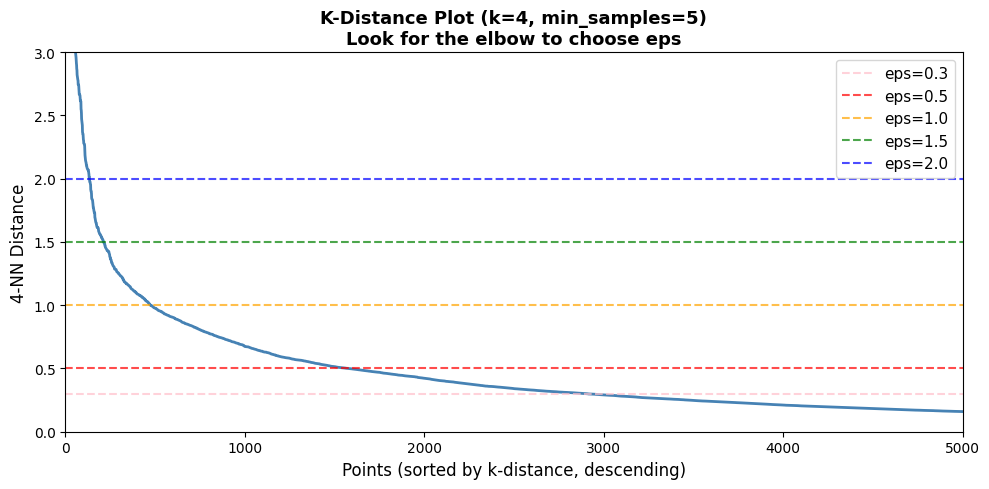

In [18]:
min_samples = 5
k = min_samples - 1  # k-distance uses k = min_samples - 1

# Fit nearest neighbors
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)

# Get the k-th neighbor distance for each point (last column)
k_distances = np.sort(distances[:, -1])[::-1]  # sort descending

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(k_distances)), k_distances, color='steelblue', linewidth=2)
ax.set_xlabel('Points (sorted by k-distance, descending)', fontsize=12)
ax.set_ylabel(f'{k}-NN Distance', fontsize=12)
ax.set_title(f'K-Distance Plot (k={k}, min_samples={min_samples})\nLook for the elbow to choose eps',
             fontsize=13, fontweight='bold')

for eps_candidate, color, label in [(0.3, 'pink', 'eps=0.3'), (0.5, 'red', 'eps=0.5'), (1.0, 'orange', 'eps=1.0'), 
                                    (1.5, 'green', 'eps=1.5'), (2.0, 'blue', 'eps=2.0')]:
    ax.axhline(y=eps_candidate, color=color, linestyle='--', alpha=0.7, label=label)

# Zoom in graph
ax.set_xlim(0, 5000)   # focus on first 5000 points where elbow is
ax.set_ylim(0, 3)      # focus on distance range 0–3

ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### **Compare $\epsilon$ Values**

In [19]:
eps_values = [0.3, 0.5, 1.0, 1.5, 2.0]
results = []

print(f"{'eps':>6}  |  {'Clusters':>9}  |  {'Noise pts':>10}  |  {'Noise %':>8}  |  {'Silhouette':>12}")
print("-" * 60)

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
    labels = db.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    noise_pct = n_noise / len(labels) * 100
    
    if n_clusters >= 2:
        # Silhouette only on non-noise points
        mask = labels != -1
        sil = silhouette_score(X_scaled[mask], labels[mask]) if mask.sum() > 1 else float('nan')
    else:
        sil = float('nan')
    
    results.append({'eps': eps, 'n_clusters': n_clusters, 'n_noise': n_noise,
                    'noise_pct': noise_pct, 'silhouette': sil, 'labels': labels})
    
    sil_str = f"{sil:.4f}" if not np.isnan(sil) else "  N/A"
    print(f"  {eps:>4}  |  {n_clusters:>9}  |  {n_noise:>10}  |  {noise_pct:>7.1f}%  |  {sil_str:>12}")

   eps  |   Clusters  |   Noise pts  |   Noise %  |    Silhouette
------------------------------------------------------------
   0.3  |         19  |        2509  |     28.0%  |       -0.0665
   0.5  |         11  |        1250  |     14.0%  |        0.2030
   1.0  |          4  |         319  |      3.6%  |        0.6124
   1.5  |          2  |         160  |      1.8%  |        0.8036
   2.0  |          3  |          94  |      1.1%  |        0.7034


| $\epsilon$  | Clusters | Noise pts | Noise % | Silhouette |
| ----- | -------- |---------- | -------- | ---------------------------- |
 | 0.3  |         21  |        2417  |     28.0%  |       -0.0799 |
 |  0.5  |         9  |        1206  |     14.0%  |        0.2591 | 
 |  1.0  |          4  |         309  |      3.6%  |        0.6076 | 
 |  1.5  |          2  |         157  |      1.8%  |        0.8042 | 
 |  2.0  |          3  |          91  |      1.1%  |        0.7062 |

#### **Insights:**

Based on the table, the best $\epsilon$ would be ``1.5`` compared to the other values.

The reasoning behind my decision is that values below 1.0 have too much noise, especially ``0.5`` and ``0.3``. Even though ``1.0`` has much more clusters (4), the lower silhouette value indicates weak internal separation. The silhouette values also indicate that, at ``1.5``, each point has a better fit in its own cluster vs. other neighborning cluster. At ``0.8042``, it has the best cluster fit in comparison to ``2.0`` which over-merge too much leading to a lower silhouette score. Due to this, we decided to choose $\epsilon = 1.5$

## **Fit DBScan with chosen $\epsilon$ value**

Final DBSCAN (eps=1.5, min_samples=5)
  Clusters found  : 2
  Noise points    : 160 (1.8%)

Cluster sizes:
    Noise (-1): 160 points (1.8%)
     Cluster 0: 8782 points (98.1%)
     Cluster 1: 8 points (0.1%)


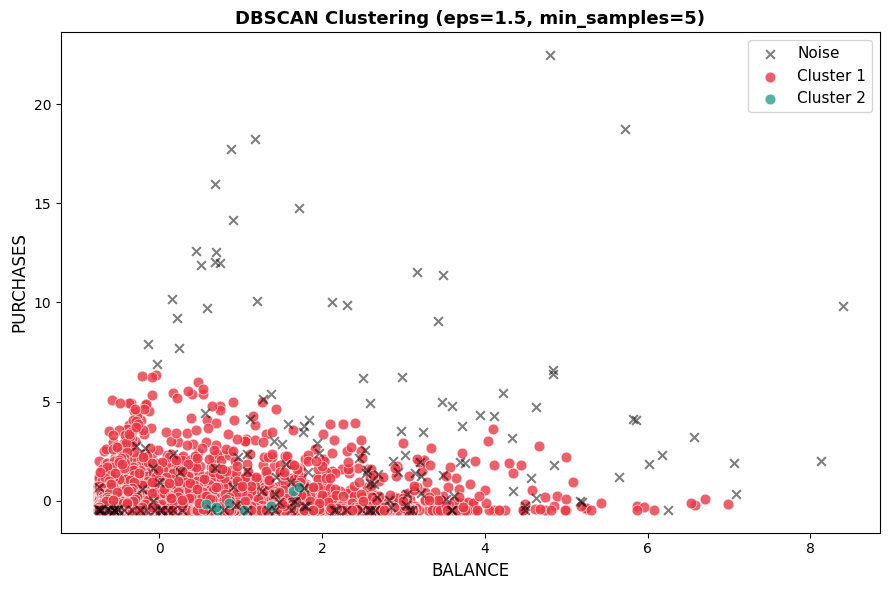

In [20]:
eps_final = 1.5
db_final = DBSCAN(eps=eps_final, min_samples=min_samples).fit(X_scaled)
clean_df['DBSCAN_Cluster'] = db_final.labels_

labels = db_final.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = (labels == -1).sum()

print(f"Final DBSCAN (eps={eps_final}, min_samples={min_samples})")
print(f"  Clusters found  : {n_clusters}")
print(f"  Noise points    : {n_noise} ({n_noise/len(labels)*100:.1f}%)")
print()
print("Cluster sizes:")
for lbl in sorted(set(labels)):
    count = (labels == lbl).sum()
    name = f"Cluster {lbl}" if lbl != -1 else "Noise (-1)"
    print(f"  {name:>12}: {count} points ({count/len(labels)*100:.1f}%)")

# Visualization
palette = ['#e63946', '#2a9d8f', '#e9c46a', '#457b9d', '#a8dadc', '#f4a261']
fig, ax = plt.subplots(figsize=(9, 6))

for lbl in sorted(set(labels)):
    mask = labels == lbl
    if lbl == -1:
        ax.scatter(X_scaled[mask, 0], X_scaled[mask, 1], c='black', s=40, alpha=0.5,
                   marker='x', zorder=5, label='Noise')
    else:
        ax.scatter(X_scaled[mask, 0], X_scaled[mask, 1], color=palette[lbl],
                   s=60, alpha=0.8, edgecolors='white', linewidth=0.5,
                   label=f'Cluster {lbl+1}')

ax.set_ylabel('PURCHASES', fontsize=12)
ax.set_xlabel('BALANCE', fontsize=12)
ax.set_title(f'DBSCAN Clustering (eps={eps_final}, min_samples={min_samples})',
             fontsize=13, fontweight='bold')

ax.legend(fontsize=11)
plt.tight_layout()

## **Silhouette Plot**

Mean silhouette score (excl. noise): 0.8036
Points included: 8790 / 8950



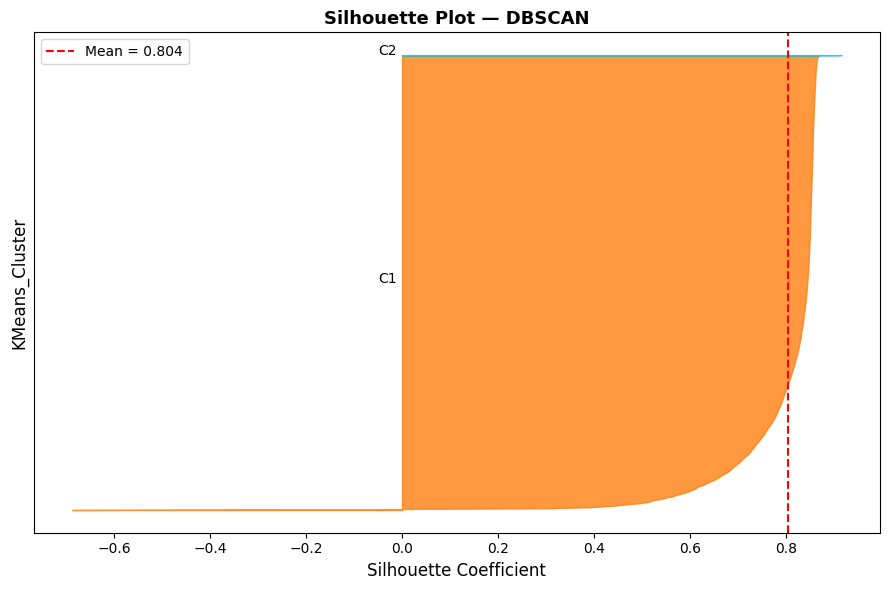

Silhouette Score: 0.7629
Davies-Bouldin Index: 1.1007
Calinski-Harabasz Index: 939.1813


In [21]:
# Exclude noise points
mask_non_noise = labels != -1
X_no_noise = X_scaled[mask_non_noise]
labels_no_noise = labels[mask_non_noise]

avg_sil = silhouette_score(X_no_noise, labels_no_noise)
sil_vals = silhouette_samples(X_no_noise, labels_no_noise)

print(f"Mean silhouette score (excl. noise): {avg_sil:.4f}")
print(f"Points included: {mask_non_noise.sum()} / {len(labels)}")
print()

# Silhouette plot
fig, ax = plt.subplots(figsize=(9, 6))
y_lower = 10
unique_cluster_labels = sorted(set(labels_no_noise))
colors = plt.cm.tab10(np.linspace(0.1, 0.9, len(unique_cluster_labels)))

for i, lbl in enumerate(unique_cluster_labels):
    cluster_sil = sil_vals[labels_no_noise == lbl]
    cluster_sil.sort()
    y_upper = y_lower + len(cluster_sil)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     facecolor=colors[i], edgecolor=colors[i], alpha=0.8)
    ax.text(-0.05, y_lower + 0.5 * len(cluster_sil), f'C{lbl+1}', fontsize=10)
    y_lower = y_upper + 10

ax.axvline(x=avg_sil, color='red', linestyle='--', linewidth=1.5,
           label=f'Mean = {avg_sil:.3f}')
ax.set_xlabel('Silhouette Coefficient', fontsize=12)
ax.set_ylabel('KMeans_Cluster', fontsize=12)
ax.set_title('Silhouette Plot — DBSCAN', fontsize=13, fontweight='bold')
ax.set_yticks([])
ax.legend()
plt.tight_layout()
plt.show()
s_score_db = silhouette_score(X_scaled, db_final.labels_)
db_index_db = davies_bouldin_score(X_scaled, db_final.labels_)
ch_index_db = calinski_harabasz_score(X_scaled, db_final.labels_)

print(f"Silhouette Score: {s_score_db:.4f}")
print(f"Davies-Bouldin Index: {db_index_db:.4f}")
print(f"Calinski-Harabasz Index: {ch_index_db:.4f}")

## **Cluster Profiling**

In [22]:
print("DBSCAN: Cluster Profiles (excl. noise)")
print("-" * 45)
db_profile = clean_df[clean_df['DBSCAN_Cluster'] != -1].groupby('DBSCAN_Cluster')[
    ["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS", "MINIMUM_PAYMENTS"]].mean().round(1)
db_profile.index = db_profile.index + 1
print(db_profile.to_string())

print()
noise_df = clean_df[clean_df['DBSCAN_Cluster'] == -1]
if len(noise_df) > 0:
    print(f"DBSCAN Noise Points Profile ({len(noise_df)} points):")
    print(noise_df[["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS", "MINIMUM_PAYMENTS"]].describe().round(2).to_string())

DBSCAN: Cluster Profiles (excl. noise)
---------------------------------------------
                BALANCE  PURCHASES  CASH_ADVANCE  CREDIT_LIMIT  PAYMENTS  MINIMUM_PAYMENTS
DBSCAN_Cluster                                                                            
1                1480.6      885.5         891.4        4353.4    1494.6             711.7
2                3799.4      838.7          60.8        3681.2     550.5           26707.4

DBSCAN Noise Points Profile (160 points):
        BALANCE  PURCHASES  CASH_ADVANCE  CREDIT_LIMIT  PAYMENTS  MINIMUM_PAYMENTS
count    160.00     160.00        160.00        160.00    160.00            160.00
mean    6058.20    7470.83       5826.41      12267.50  14883.61           6863.90
std     4176.65    9850.42       7832.59       5388.68  10136.34          11797.80
min        4.38       0.00          0.00       1200.00     92.87             16.95
25%     2854.50     126.93          0.00       8500.00   6788.80            968.54
50%     53

# **Comparison and Recommendation**

## **Scatterplot Comparison: K-Means vs. DBScan**

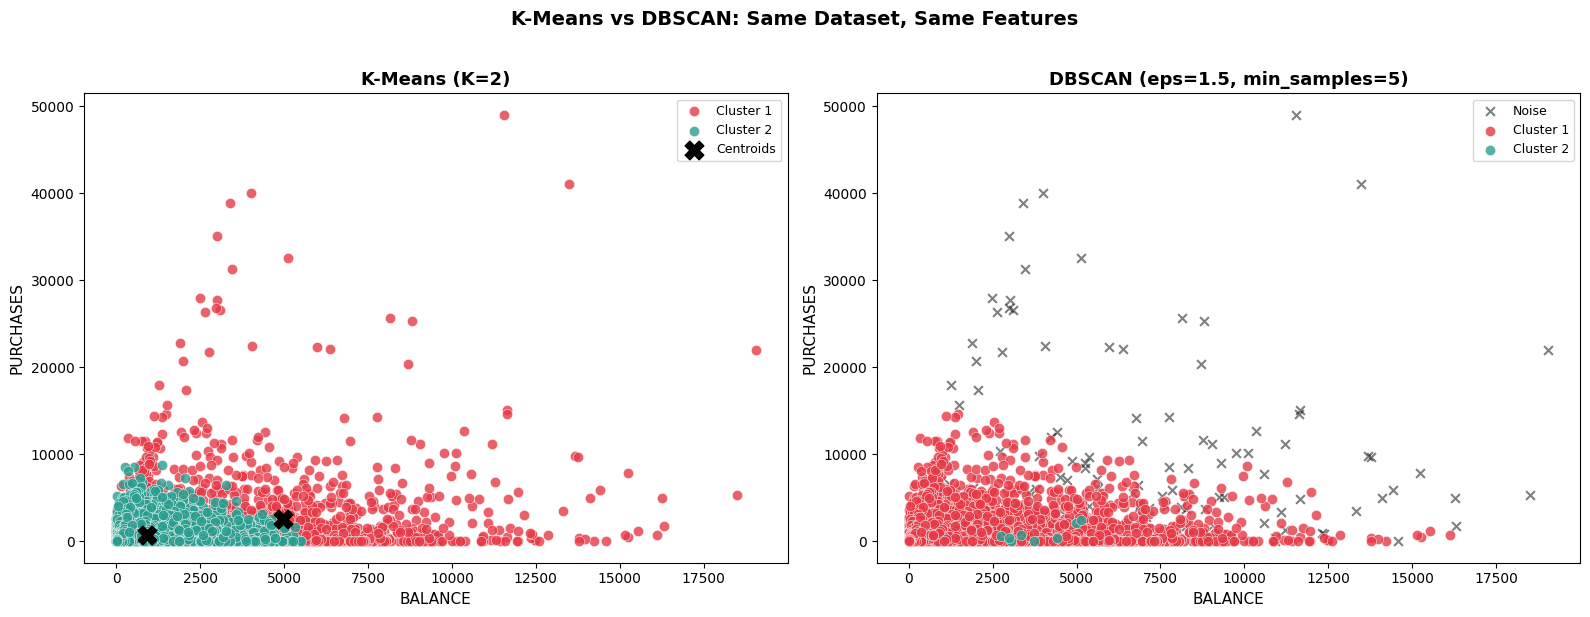

In [23]:
km = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=42, max_iter=300)
clean_df['KMeans_Cluster'] = km.fit_predict(X_scaled)

km_labels = clean_df['KMeans_Cluster'].values
db_labels = clean_df['DBSCAN_Cluster'].values

# Side-by-side scatter plots
palette_km = ['#e63946', '#2a9d8f', '#e9c46a', '#457b9d', '#a8dadc']
palette_db = ['#e63946', '#2a9d8f', '#e9c46a', '#457b9d', '#a8dadc', '#f4a261']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# K-Means
for i in range(K_final):
    mask = km_labels == i
    ax1.scatter(X[mask, 0], X[mask, 1], color=palette_km[i], s=55,
                alpha=0.8, edgecolors='white', linewidth=0.4, label=f'Cluster {i+1}')
centers_orig = scaler.inverse_transform(km.cluster_centers_)
ax1.scatter(centers_orig[:, 0], centers_orig[:, 1], c='black', marker='X',
            s=180, zorder=5, label='Centroids')
ax1.set_title(f'K-Means (K={K_final})', fontsize=13, fontweight='bold')
ax1.set_xlabel('BALANCE', fontsize=11)
ax1.set_ylabel('PURCHASES', fontsize=11)
ax1.legend(fontsize=9)

# DBSCAN
for lbl in sorted(set(db_labels)):
    mask = db_labels == lbl
    if lbl == -1:
        ax2.scatter(X[mask, 0], X[mask, 1], c='black', s=40, alpha=0.5,
                    marker='x', label='Noise')
    else:
        ax2.scatter(X[mask, 0], X[mask, 1], color=palette_db[lbl], s=55,
                    alpha=0.8, edgecolors='white', linewidth=0.4, label=f'Cluster {lbl+1}')
ax2.set_title(f'DBSCAN (eps={eps_final}, min_samples={min_samples})', fontsize=13, fontweight='bold')
ax2.set_xlabel('BALANCE', fontsize=11)
ax2.set_ylabel('PURCHASES', fontsize=11)
ax2.legend(fontsize=9)

plt.suptitle('K-Means vs DBSCAN: Same Dataset, Same Features',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# **References**
Google Gemini. (n.d.). Gemini. https://gemini.google.com/